In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.concat([
    pd.read_csv('../results/r2_baseline.csv'), 
    pd.read_csv('../results/r2_ml_cf_rfc.csv'), 
])
df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['reval_pending'] = df.revals - df.hit_reval - df.reval_wasted
df['fresh_pc'] = df.hit_fresh / df['all'] * 100
df['reval_pc'] = df.hit_reval / df['all'] * 100
df['miss_pc'] = df['miss_all'] / df['all'] * 100
df['miss_non1st_pc'] = (df.miss_expired + df.miss_evicted) / df['all'] * 100
df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['reval_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2
df.head()

,in,gib,ksr,mode,model,mlthres,rv_min_ttl,rv_min_freq,rv_max_za,all,...,reval_wasted,miss_all,reval_pending,fresh_pc,reval_pc,miss_pc,miss_non1st_pc,amp_lower,amp_upper,amp_avg
0,cf_g,2048,1,oracle,NaN,1.0,0,0,0,305423259,...,9850,44913972,0,83.596194,1.698321,14.705485,4.674395,1.000197,1.000197,1.000197
1,cf_g,2048,1,never,NaN,1.0,0,0,0,305423259,...,0,49327951,0,83.849314,0.000000,16.150686,6.119595,1.000000,1.000000,1.000000
2,cf_h,2048,1,never,NaN,1.0,0,0,0,322920612,...,0,46640120,0,85.556784,0.000000,14.443216,5.367501,1.000000,1.000000,1.000000
3,fb_a,2048,1,oracle,NaN,1.0,0,0,0,50114817,...,0,24151703,0,51.185612,0.621648,48.192739,18.848033,1.000000,1.000000,1.000000
4,fb_a,2048,1,never,NaN,1.0,0,0,0,50114817,...,0,24439860,0,51.232267,0.000000,48.767733,19.423026,1.000000,1.000000,1.000000


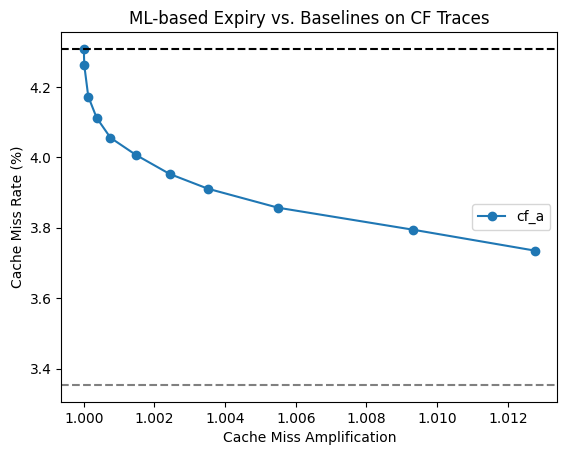

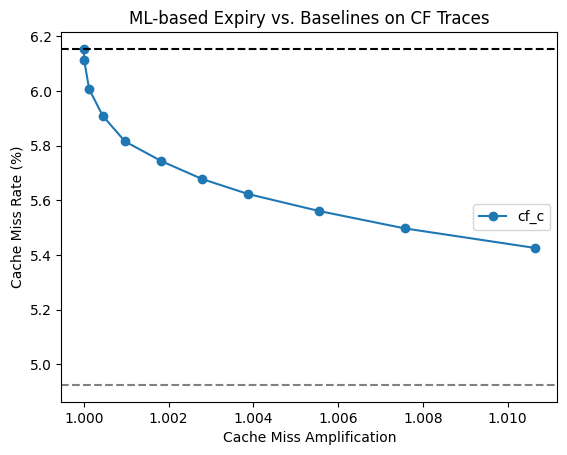

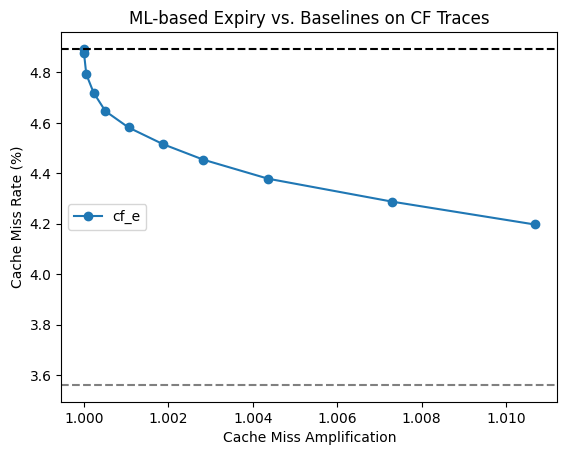

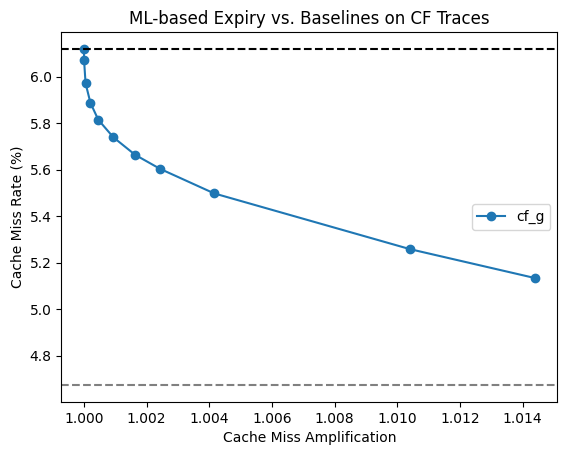

In [21]:
for s in ['cf_a', 'cf_c', 'cf_e', 'cf_g']:
    df_s = df[(df['in'] == s) & (df['mode'] == 'ml')].sort_values('mlthres')
    plt.plot(df_s['amp_avg'], df_s['miss_non1st_pc'], marker='o', label=s)
    oracle_y = df[(df['in'] == s) & (df['mode'] == 'oracle')]['miss_non1st_pc']
    plt.axhline(y=oracle_y.values[0], color='gray', linestyle='--')
    never_y = df[(df['in'] == s) & (df['mode'] == 'never')]['miss_non1st_pc']
    plt.axhline(y=never_y.values[0], color='black', linestyle='--')
    plt.xlabel('Cache Miss Amplification')
    plt.ylabel('Cache Miss Rate (%)')
    plt.title('ML-based Expiry vs. Baselines on CF Traces')
    plt.legend()
    plt.show()


In [17]:
never_y

Series([], Name: miss_non1st_pc, dtype: float64)